


**Nombre:** Gabriel Salguero
**Fecha:** 01/04/2026


Image dimensions:  (256, 256, 3)


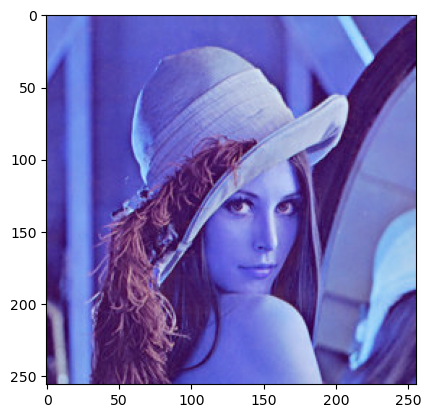

In [1]:
##ROBERTO CARRILLO
# READ AN IMAGE
# pip install opencv-python
import matplotlib.pyplot as plt
import cv2
import numpy as np


img = cv2.imread('images/images/Lena_RGB.png')
print('Image dimensions: ', np.shape(img))

plt.imshow(img, cmap='gray')
plt.show()

In [2]:
# Extraer por separado la imagen de grises de cada canal
R = img[:,:,2]
G = img[:,:,1]
B = img[:,:,0]

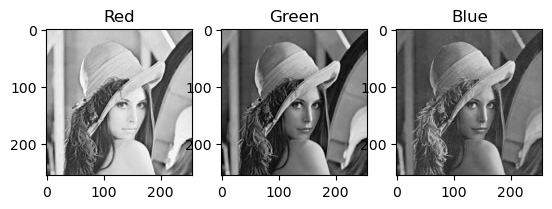

In [3]:
# Visualizar los canales en un subplot
fig, ax = plt.subplots(1,3)
ax[0].imshow(R, cmap='gray'), ax[0].set_title('Red')
ax[1].imshow(G, cmap='gray'), ax[1].set_title('Green')
ax[2].imshow(B, cmap='gray'), ax[2].set_title('Blue')
plt.show()

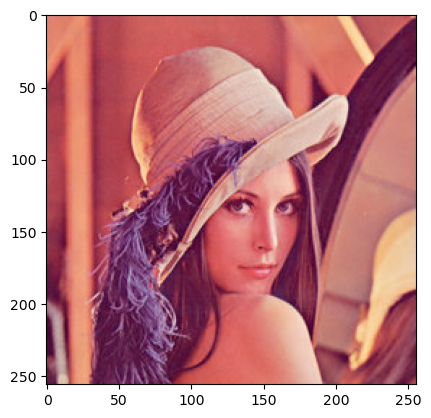

In [4]:
# Convertir BGR en RGB
RGB_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(RGB_img, cmap='gray')
plt.show()

### TRANSFORMACIONES DE INTENSIDAD

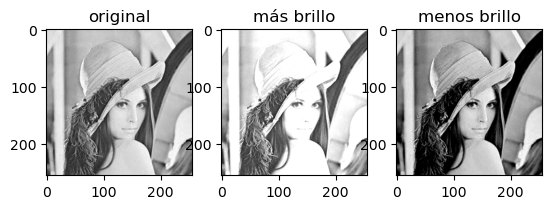

In [5]:
# CAMBIO DE BRILLO
img = cv2.imread('images/images/Lena_RGB.png')
img = img[:,:,2] # red color

mas_brillo = 50
menos_brillo = -100
mas_brillo_img = cv2.add(img, mas_brillo) # Importante el "cv2.add" en vez de "+"
menos_brillo_img = cv2.add(img, menos_brillo)

fig, ax = plt.subplots(1,3)
ax[0].imshow(img, cmap='gray'), ax[0].set_title('original')
ax[1].imshow(mas_brillo_img, cmap='gray'), ax[1].set_title('más brillo')
ax[2].imshow(menos_brillo_img, cmap='gray'), ax[2].set_title('menos brillo')
plt.show()

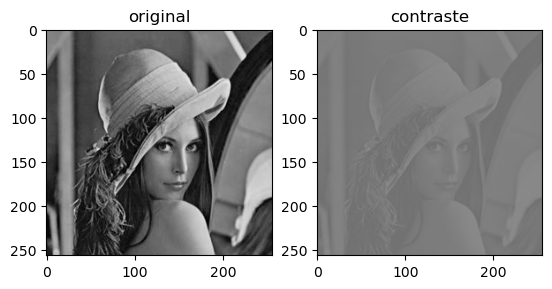

In [6]:
# CAMBIO DE CONTRASTE de acuerdo con el programa GIMP
img = cv2.imread('images/images/Lena_RGB.png')
img = img[:,:,1] # canal verde

contraste = -100

f = 131*(contraste + 127)/(127*(131-contraste))
alpha_c = f
gamma_c = 127*(1-f)

contrast_img = cv2.addWeighted(img, alpha_c, img, 0, gamma_c)

fig, ax = plt.subplots(1,2)
ax[0].imshow(img, cmap='gray', vmin=0, vmax=255), ax[0].set_title('original')
ax[1].imshow(contrast_img, cmap='gray', vmin=0, vmax=255), ax[1].set_title('contraste')
plt.show()

### CONVERSIONES DEL ESPACIO DE COLOR

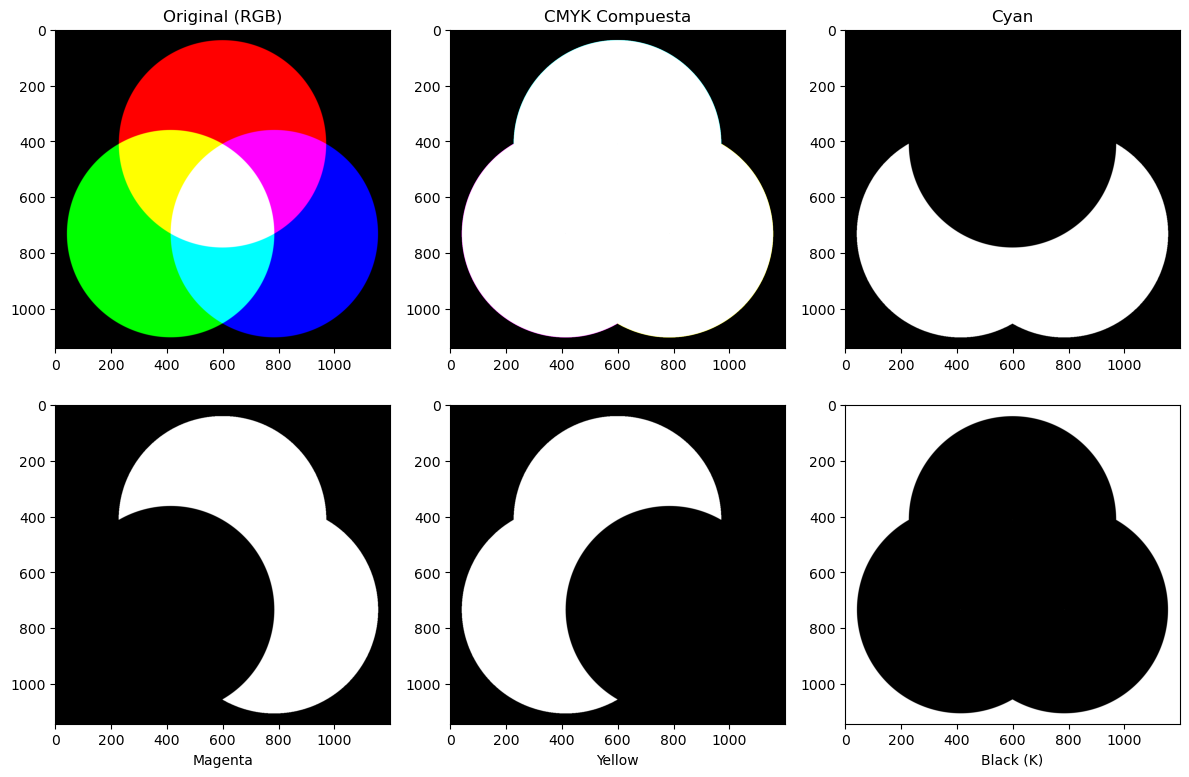

In [7]:
import numpy as np
from skimage import io
import cv2
import matplotlib.pyplot as plt

# 1. Cargar imagen y normalizar
img = io.imread('images/images/colores.png')
rgb = img.copy()
# Convertimos a float y normalizamos a [0, 1]
rgb_p = rgb.astype('float32') / 255

with np.errstate(invalid='ignore', divide='ignore'):
    # 2. Calcular el canal Negro (K)
    K = 1 - np.max(rgb_p, axis=2)
    
    # 3. Extraer canales R, G, B para las fórmulas
    R = rgb_p[:, :, 0]
    G = rgb_p[:, :, 1]
    B = rgb_p[:, :, 2]
    
    # 4. Calcular Cyan, Magenta y Amarillo
    # La fórmula es (1 - Color - K) / (1 - K)
    C = (1 - R - K) / (1 - K)
    M = (1 - G - K) / (1 - K)
    Y = (1 - B - K) / (1 - K)

    # 5. Manejar el caso de negro puro (donde K=1 y habría división por cero)
    C = np.nan_to_num(C)
    M = np.nan_to_num(M)
    Y = np.nan_to_num(Y)

# 6. Unir canales y volver a rango 0-255
CMYK = (np.dstack((C, M, Y, K)) * 255).astype('uint8')
C_img, M_img, Y_img, K_img = cv2.split(CMYK)

# 7. Visualización
fig, ax = plt.subplots(2, 3, figsize=(12, 8))
ax[0, 0].imshow(img), ax[0, 0].set_title('Original (RGB)')
ax[0, 1].imshow(CMYK), ax[0, 1].set_title('CMYK Compuesta')
ax[0, 2].imshow(C_img, cmap='gray'), ax[0, 2].set_title('Cyan')
ax[1, 0].imshow(M_img, cmap='gray'), ax[1, 0].set_xlabel('Magenta')
ax[1, 1].imshow(Y_img, cmap='gray'), ax[1, 1].set_xlabel('Yellow')
ax[1, 2].imshow(K_img, cmap='gray'), ax[1, 2].set_xlabel('Black (K)')

plt.tight_layout()
plt.show()

In [8]:
# Otras conversiones

img = cv2.imread('images/images/Lena_RGB.png')

gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) # gray-scale

HSV = cv2.cvtColor(img, cv2.COLOR_BGR2HSV) # (H)ue, (S)aturation and (V)alue

Lab = cv2.cvtColor(img, cv2.COLOR_BGR2Lab) # (L)uminosidad, a-b colores complementarios

YCrCb = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb) # Y-Luma, Cr-Cb crominancia rojo y azul


### TRANSFORMACIONES GEOMÉTRICAS

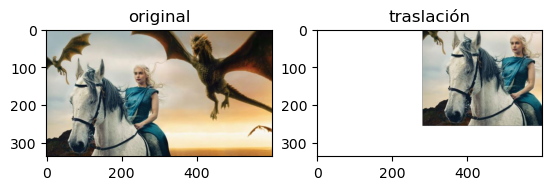

In [9]:
# TRASLACIÓN
from skimage import io
img = io.imread('images/images/GOT.png')
rows, cols, ch = img.shape
 
M = np.float32([[1,0,280],[0,1,-80]]) # Defino la matriz de transformación
new_img = cv2.warpAffine(img,M,(cols,rows)) # Aplico la transformación

figs, ax = plt.subplots(1,2)
ax[0].imshow(img, cmap='gray'), ax[0].set_title('original')
ax[1].imshow(new_img, cmap='gray'), ax[1].set_title('traslación')
plt.show()

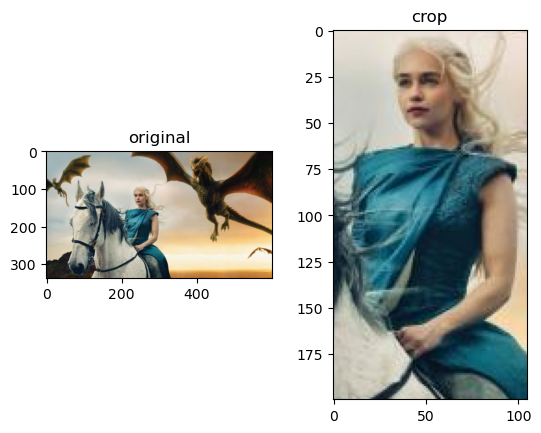

In [10]:
# CROPPING
from skimage import io
img = io.imread('images/images/GOT.png')

new_img = img[90:290, 200:305]

figs, ax = plt.subplots(1,2)
ax[0].imshow(img, cmap='gray'), ax[0].set_title('original')
ax[1].imshow(new_img, cmap='gray'), ax[1].set_title('crop')
plt.show()

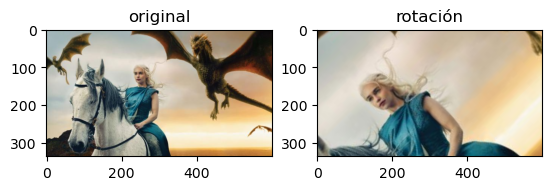

In [11]:
# ROTACIÓN
from skimage import io
img = io.imread('images/images/GOT.png')
rows, cols, ch = img.shape

M = cv2.getRotationMatrix2D((cols/2,rows/2),angle=45,scale=2) # Defino la matriz de transformación
new_img = cv2.warpAffine(img,M,(cols,rows)) # Aplico la transformación

figs, ax = plt.subplots(1,2)
ax[0].imshow(img, cmap='gray'), ax[0].set_title('original')
ax[1].imshow(new_img, cmap='gray'), ax[1].set_title('rotación')
plt.show()

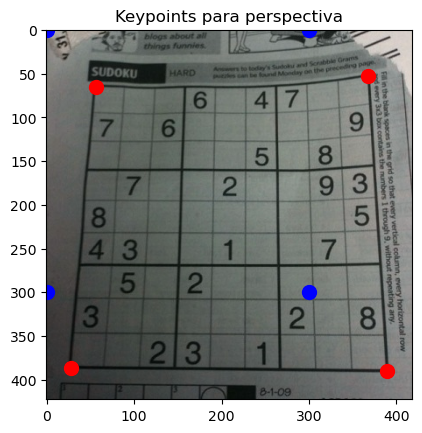

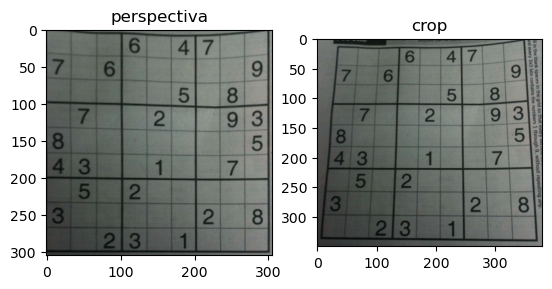

In [12]:
# PERSPECTIVA
img = cv2.imread('images/images/sudoku.png')
rows, cols, ch = img.shape
 
pts1 = np.float32([[56,65],[368,52],[28,387],[389,390]])
pts2 = np.float32([[0,0],[300,0],[0,300],[300,300]])

plt.imshow(img, cmap='gray')
for i in range(0,4):
    plt.plot(pts1[i,0], pts1[i,1], 'or', markersize=10)
    plt.plot(pts2[i,0], pts2[i,1], 'ob', markersize=10)
plt.title('Keypoints para perspectiva')
plt.show()
 
M = cv2.getPerspectiveTransform(pts1,pts2) # Defino la matriz de transformación
pers = cv2.warpPerspective(img,M,(305,305)) # Aplico la transformación
crop =  img[50:400,20:400]

figs, ax = plt.subplots(1,2)
ax[0].imshow(pers, cmap='gray'), ax[0].set_title('perspectiva')
ax[1].imshow(crop, cmap='gray'), ax[1].set_title('crop')
plt.show()


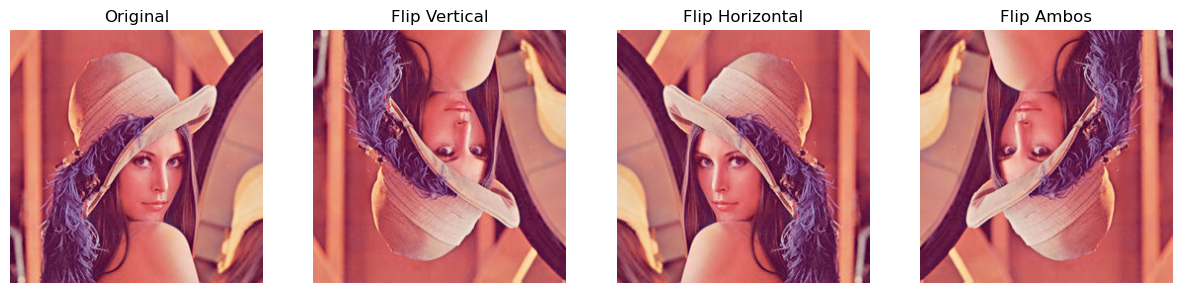

In [13]:
import cv2
import matplotlib.pyplot as plt
from skimage import io

# 1. Leer la imagen

img = io.imread('images/images/Lena_RGB.png')

# 2. Voltear la imagen

flipVertical = cv2.flip(img, 0)


flipHorizontal = cv2.flip(img, 1)

flipBoth = cv2.flip(img, -1)

# 3. Visualización
figs, ax = plt.subplots(1, 4, figsize=(15, 5))
ax[0].imshow(img), ax[0].set_title('Original')
ax[1].imshow(flipVertical), ax[1].set_title('Flip Vertical')
ax[2].imshow(flipHorizontal), ax[2].set_title('Flip Horizontal')
ax[3].imshow(flipBoth), ax[3].set_title('Flip Ambos')

# Limpiar los ejes 
for a in ax:
    a.axis('off')

plt.show()

https://github.com/reromash1/machines2